In [60]:
!uv pip install numpy matplotlib folium

Using Python 3.12.5 environment at: /home/linux/Documents/openpilot/.venv
Audited 3 packages in 2ms


In [61]:
from openpilot.tools.lib.logreader import LogReader, Route
import numpy as np
import matplotlib.pyplot as plt
import folium
import os
import codecs
plt.style.use('fivethirtyeight')
codecs.register_error("strict", codecs.backslashreplace_errors)

In [62]:
# get all route segments by prefix
# routes_dir = '/home/linux/.comma/media/0/realdata'
routes_dir = '/mnt/sdd1/op_log/XXXXXXXXXXXXXXXX'
routes = [f for f in os.listdir(routes_dir) if f.startswith('00000016--1f0d3c3a72')]
routes_rlog = [os.path.join(routes_dir, route, "rlog.zst") for route in routes if os.path.isfile(os.path.join(routes_dir, route, "rlog.zst"))]
routes_rlog.sort(key=lambda x: os.path.getmtime(x))

In [63]:
routes_rlog

['/mnt/sdd1/op_log/XXXXXXXXXXXXXXXX/00000016--1f0d3c3a72--0/rlog.zst',
 '/mnt/sdd1/op_log/XXXXXXXXXXXXXXXX/00000016--1f0d3c3a72--1/rlog.zst',
 '/mnt/sdd1/op_log/XXXXXXXXXXXXXXXX/00000016--1f0d3c3a72--10/rlog.zst',
 '/mnt/sdd1/op_log/XXXXXXXXXXXXXXXX/00000016--1f0d3c3a72--11/rlog.zst',
 '/mnt/sdd1/op_log/XXXXXXXXXXXXXXXX/00000016--1f0d3c3a72--12/rlog.zst',
 '/mnt/sdd1/op_log/XXXXXXXXXXXXXXXX/00000016--1f0d3c3a72--2/rlog.zst',
 '/mnt/sdd1/op_log/XXXXXXXXXXXXXXXX/00000016--1f0d3c3a72--3/rlog.zst',
 '/mnt/sdd1/op_log/XXXXXXXXXXXXXXXX/00000016--1f0d3c3a72--4/rlog.zst',
 '/mnt/sdd1/op_log/XXXXXXXXXXXXXXXX/00000016--1f0d3c3a72--5/rlog.zst',
 '/mnt/sdd1/op_log/XXXXXXXXXXXXXXXX/00000016--1f0d3c3a72--6/rlog.zst',
 '/mnt/sdd1/op_log/XXXXXXXXXXXXXXXX/00000016--1f0d3c3a72--7/rlog.zst',
 '/mnt/sdd1/op_log/XXXXXXXXXXXXXXXX/00000016--1f0d3c3a72--8/rlog.zst',
 '/mnt/sdd1/op_log/XXXXXXXXXXXXXXXX/00000016--1f0d3c3a72--9/rlog.zst']

In [64]:
mapping = []
for rlog in routes_rlog:
    lr = LogReader(rlog)
    for msg in lr:
        if msg.which() == 'gpsLocationExternal':
            gps = msg.as_builder().gpsLocationExternal
            lat, lon = gps.latitude, gps.longitude
            mapping.append((lat, lon))


In [65]:
# map the map
m = folium.Map(location=[mapping[0][0], mapping[0][1]], zoom_start=25)
folium.PolyLine(mapping, color='blue', weight=2.5, opacity=1).add_to(m)
# Add markers for start and end points
folium.Marker(location=mapping[0], popup="Start Point", icon=folium.Icon(color="green")).add_to(m)
folium.Marker(location=mapping[-1], popup="End Point", icon=folium.Icon(color="red")).add_to(m)
display(m)

In [66]:
phy_speed = []
rtt = []
disconnect_samples = 0
for rlog in routes_rlog:
    lr = LogReader(rlog)
    for msg in lr:
        if msg.which() == 'customReserved5':
            phy = msg.as_builder().customReserved5
            if phy.wifiConnected and phy.wifiFrequency > 0:
                phy_speed.append((phy.wifiPhyTxRate, phy.wifiPhyRxRate, phy.wifiSignalStrength))
            else:
                disconnect_samples += 1
        if msg.which() == 'customReserved6':
            r = msg.as_builder().customReserved6
            if r.rtt > 0:
                rtt.append(r.rtt)


In [67]:
# calulate disconnect rate
total_samples = len(phy_speed) + disconnect_samples
disconnect_rate = disconnect_samples / total_samples * 100
print(f"Disconnect rate: {disconnect_rate:.2f}% ({disconnect_samples}/{total_samples})")

Disconnect rate: 0.00% (0/739)


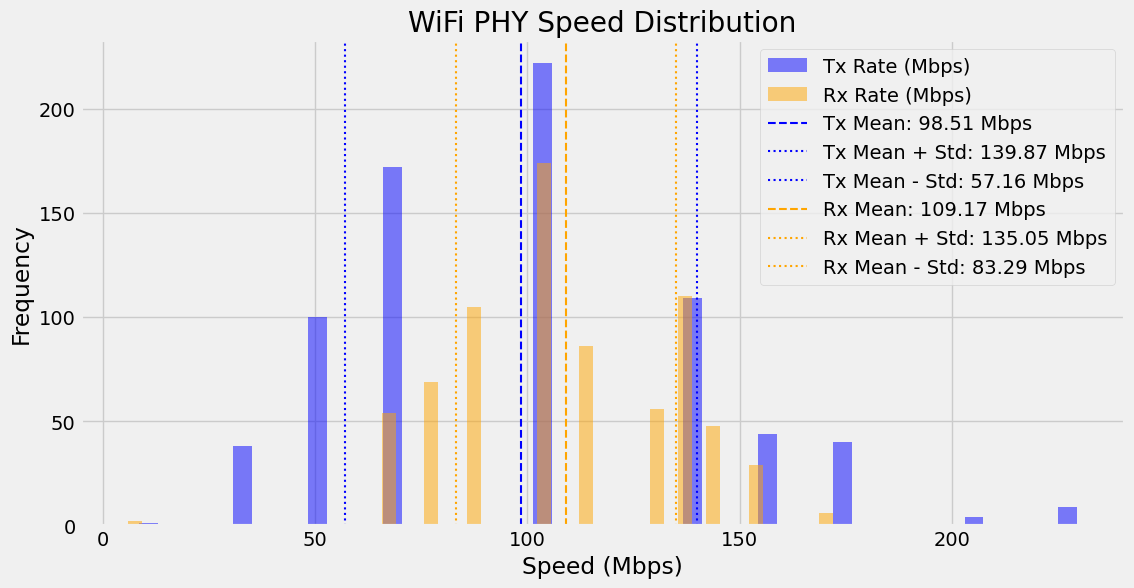

In [68]:
# plot histogram for phy speed
phy_speed = np.array(phy_speed)
plt.figure(figsize=(12, 6))
plt.hist(phy_speed[:, 0], bins=50, alpha=0.5, label='Tx Rate (Mbps)', color='blue')
mean_tx = np.mean(phy_speed[:, 0])
std_tx = np.std(phy_speed[:, 0])
mean_rx = np.mean(phy_speed[:, 1])
std_rx = np.std(phy_speed[:, 1])

plt.hist(phy_speed[:, 1], bins=50, alpha=0.5, label='Rx Rate (Mbps)', color='orange')
plt.axvline(mean_tx, color='blue', linestyle='dashed', linewidth=1.5, label=f'Tx Mean: {mean_tx:.2f} Mbps')
plt.axvline(mean_tx + std_tx, color='blue', linestyle='dotted', linewidth=1.5, label=f'Tx Mean + Std: {mean_tx + std_tx:.2f} Mbps')
plt.axvline(mean_tx - std_tx, color='blue', linestyle='dotted', linewidth=1.5, label=f'Tx Mean - Std: {mean_tx - std_tx:.2f} Mbps')
plt.axvline(mean_rx, color='orange', linestyle='dashed', linewidth=1.5, label=f'Rx Mean: {mean_rx:.2f} Mbps')
plt.axvline(mean_rx + std_rx, color='orange', linestyle='dotted', linewidth=1.5, label=f'Rx Mean + Std: {mean_rx + std_rx:.2f} Mbps')
plt.axvline(mean_rx - std_rx, color='orange', linestyle='dotted', linewidth=1.5, label=f'Rx Mean - Std: {mean_rx - std_rx:.2f} Mbps')
plt.xlabel('Speed (Mbps)')
plt.ylabel('Frequency')
plt.title('WiFi PHY Speed Distribution')
plt.legend()
plt.show()

In [69]:
# calculate phy stats
phy_speed_np = np.array(phy_speed)
phy_speed_mean = np.mean(phy_speed_np, axis=0)
phy_speed_std = np.std(phy_speed_np, axis=0)
print(f"Phy Tx Rate Mean: {phy_speed_mean[0]:.2f} Mbps, Std: {phy_speed_std[0]:.2f} Mbps")
print(f"Phy Rx Rate Mean: {phy_speed_mean[1]:.2f} Mbps, Std: {phy_speed_std[1]:.2f} Mbps")
# 99, 95, 90 percentiles
phy_speed_percentiles = np.percentile(phy_speed_np, [99, 95, 90], axis=0)
print(f"Phy Tx Rate 99th Percentile: {phy_speed_percentiles[0][0]:.2f} Mbps, 95th Percentile: {phy_speed_percentiles[1][0]:.2f} Mbps, 90th Percentile: {phy_speed_percentiles[2][0]:.2f} Mbps")
print(f"Phy Rx Rate 99th Percentile: {phy_speed_percentiles[0][1]:.2f} Mbps, 95th Percentile: {phy_speed_percentiles[1][1]:.2f} Mbps, 90th Percentile: {phy_speed_percentiles[2][1]:.2f} Mbps")

Phy Tx Rate Mean: 98.51 Mbps, Std: 41.36 Mbps
Phy Rx Rate Mean: 109.17 Mbps, Std: 25.88 Mbps
Phy Tx Rate 99th Percentile: 229.40 Mbps, 95th Percentile: 172.00 Mbps, 90th Percentile: 154.80 Mbps
Phy Rx Rate 99th Percentile: 154.80 Mbps, 95th Percentile: 143.30 Mbps, 90th Percentile: 143.30 Mbps


In [70]:
# pre filter rtt > 50ms
rtt_np = np.array(rtt) * 1000  # convert to ms

timeout_count = np.sum(rtt_np > 50)
print(f"RTT Count: {len(rtt_np)}, Timeouts (>50ms): {timeout_count} ({timeout_count/len(rtt_np)*100:.2f}%)")
# only keep rtt <= 50ms
rtt_np = rtt_np[rtt_np <= 50]
rtt_np

RTT Count: 3697, Timeouts (>50ms): 75 (2.03%)


array([4.34803963, 4.02140617, 5.94902039, ..., 4.6787262 , 4.31847572,
       4.25577164])

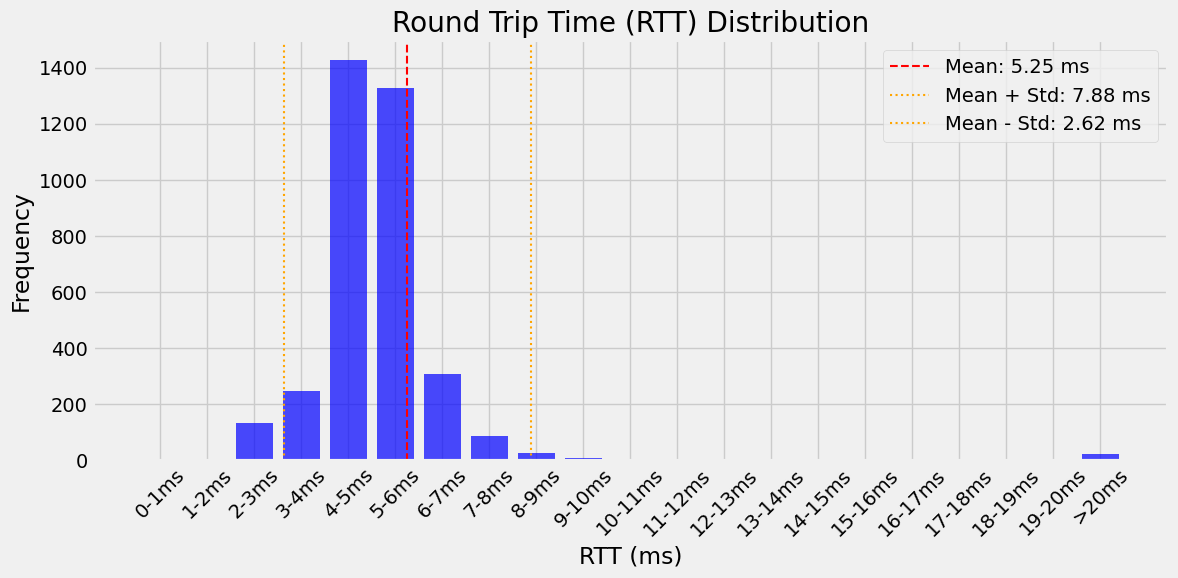

In [71]:
# Create a histogram for RTT values
plt.figure(figsize=(12, 6))

# Define bins for RTT values
bins = np.arange(0, 21, 1).tolist()  # Bins from 0ms to 20ms
bins.append(np.max(rtt_np))  # Add a bin for values greater than 20ms

# Create labels for bins
bin_labels = [f"{i}-{i+1}ms" for i in range(20)]
bin_labels.append(">20ms")

# Categorize RTT values into bins
rtt_np_clipped = np.clip(rtt_np, 0, 20)  # Clip values to 20ms for visualization
hist, edges = np.histogram(rtt_np_clipped, bins=bins)

# Plot histogram
plt.bar(bin_labels, hist, color='blue', alpha=0.7)

# Add mean and std lines
mean_rtt = np.mean(rtt_np)
std_rtt = np.std(rtt_np)
plt.axvline(mean_rtt, color='red', linestyle='dashed', linewidth=1.5, label=f'Mean: {mean_rtt:.2f} ms')
plt.axvline(mean_rtt + std_rtt, color='orange', linestyle='dotted', linewidth=1.5, label=f'Mean + Std: {mean_rtt + std_rtt:.2f} ms')
plt.axvline(mean_rtt - std_rtt, color='orange', linestyle='dotted', linewidth=1.5, label=f'Mean - Std: {mean_rtt - std_rtt:.2f} ms')

# Add labels and legend
plt.xlabel('RTT (ms)')
plt.ylabel('Frequency')
plt.title('Round Trip Time (RTT) Distribution')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [72]:
# calculate stats for rtt samples
print(f"RTT samples: {len(rtt_np)}")
print(f"RTT mean: {np.mean(rtt_np):.2f} ms")
print(f"RTT std: {np.std(rtt_np):.2f} ms")
print(f"RTT min: {np.min(rtt_np):.2f} ms")
print(f"RTT max: {np.max(rtt_np):.2f} ms")
# 99, 95, 90 percentiles
print(f"RTT 99th percentile: {np.percentile(rtt_np, 99):.2f} ms")
print(f"RTT 95th percentile: {np.percentile(rtt_np, 95):.2f} ms")
print(f"RTT 90th percentile: {np.percentile(rtt_np, 90):.2f} ms")

RTT samples: 3622
RTT mean: 5.25 ms
RTT std: 2.63 ms
RTT min: 1.85 ms
RTT max: 48.52 ms
RTT 99th percentile: 11.75 ms
RTT 95th percentile: 6.93 ms
RTT 90th percentile: 6.26 ms


In [73]:
import bisect

# Collect all messages with timestamps
all_gps_msgs = []
all_phy_msgs = []
all_rtt_msgs = []

for rlog in routes_rlog:
  lr = LogReader(rlog)
  for msg in lr:
    if msg.which() == 'gpsLocationExternal':
      all_gps_msgs.append((msg.logMonoTime, msg.as_builder().gpsLocationExternal))
    elif msg.which() == 'customReserved5':
      all_phy_msgs.append((msg.logMonoTime, msg.as_builder().customReserved5))
    elif msg.which() == 'customReserved6':
      all_rtt_msgs.append((msg.logMonoTime, msg.as_builder().customReserved6))

# Sort messages by timestamp
all_gps_msgs.sort(key=lambda x: x[0])
all_phy_msgs.sort(key=lambda x: x[0])
all_rtt_msgs.sort(key=lambda x: x[0])

# Function to find the closest message within a tolerance
def find_closest_msg(target_time, msg_list, tolerance_ns):
  if not msg_list:
    return None

  # Find the index where target_time would be inserted
  # This gives us the index of the first element >= target_time
  timestamps = [ts for ts, msg in msg_list]
  idx = bisect.bisect_left(timestamps, target_time)

  closest_msg = None
  min_diff = float('inf')

  # Check the element at idx (if it exists)
  if idx < len(msg_list):
    ts, msg = msg_list[idx]
    diff = abs(target_time - ts)
    if diff <= tolerance_ns:
      closest_msg = msg
      min_diff = diff

  # Check the element before idx (if it exists)
  if idx > 0:
    ts, msg = msg_list[idx - 1]
    diff = abs(target_time - ts)
    if diff <= tolerance_ns:
      # If this one is closer, update
      if diff < min_diff:
         closest_msg = msg
         min_diff = diff
      # If diff == min_diff, the one at idx was already selected, which is fine.

  return closest_msg

# Synchronize messages
synchronized_data = []
tolerance_ns = 50_000_000 # 50 ms

# Iterate through GPS messages and find closest PHY and RTT messages
for gps_time, gps_msg in all_gps_msgs:
  # Find closest phy message
  closest_phy_msg = find_closest_msg(gps_time, all_phy_msgs, tolerance_ns)

  # Find closest rtt message
  closest_rtt_msg = find_closest_msg(gps_time, all_rtt_msgs, tolerance_ns)

  # If both are found within tolerance, add to synchronized data
  if closest_phy_msg is not None and closest_rtt_msg is not None:
    synchronized_data.append({
      'timestamp': gps_time, # Use GPS time as the reference
      'gps': gps_msg,
      'phy': closest_phy_msg,
      'rtt': closest_rtt_msg
    })

print(f"Collected {len(all_gps_msgs)} GPS messages")
print(f"Collected {len(all_phy_msgs)} PHY messages")
print(f"Collected {len(all_rtt_msgs)} RTT messages")
print(f"Synchronized {len(synchronized_data)} triplets within {tolerance_ns / 1e6} ms tolerance")

# The 'synchronized_data' list now contains dictionaries, where each dictionary
# represents a synchronized triplet of messages (gps, phy, rtt) anchored by
# the GPS message's timestamp, provided the other messages were found within
# the specified tolerance.

Collected 6893 GPS messages
Collected 739 PHY messages
Collected 3697 RTT messages
Synchronized 319 triplets within 50.0 ms tolerance


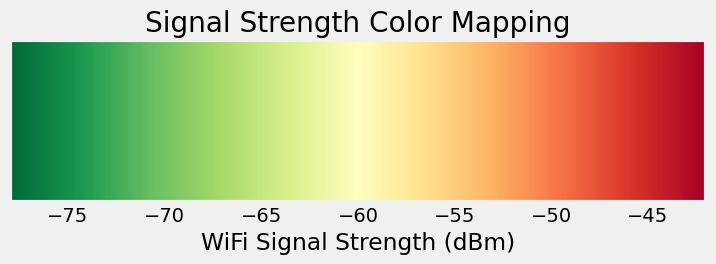

In [74]:
import matplotlib.colors

# plot the map with color line where the color represents the signal strength
# Calculate min and max signal strength for color mapping
min_dbm = np.min(phy_speed_np[:, 2])
max_dbm = np.max(phy_speed_np[:, 2])

# Define a colormap (e.g., green to red)
# Using RdYlGn_r (Red-Yellow-Green reversed)
cmap = plt.cm.RdYlGn_r

# Function to map signal strength (dBm) to a color
def get_color_from_dbm(dbm, min_val, max_val, cmap):
    # Normalize the dBm value to the range [0, 1]
    # Clip the value to handle potential outliers outside the min/max range
    normalized_strength = np.clip((dbm - min_val) / (max_val - min_val), 0, 1)
    # Get the color from the colormap
    rgba_color = cmap(normalized_strength)
    # Convert RGBA to hex color string for Folium
    hex_color = matplotlib.colors.to_hex(rgba_color)
    return hex_color

# Plot the color mapping
plt.figure(figsize=(8, 2))
ax = plt.gca()
# Create a colorbar base
norm = matplotlib.colors.Normalize(vmin=min_dbm, vmax=max_dbm)
cbar = matplotlib.colorbar.ColorbarBase(ax, cmap=cmap, norm=norm, orientation='horizontal') # Use the imported module
cbar.set_label('WiFi Signal Strength (dBm)')
plt.title('Signal Strength Color Mapping')
plt.show()

# Now plot the map using the gradient color
m = folium.Map(location=[mapping[0][0], mapping[0][1]], zoom_start=25)
for data in synchronized_data:
    lat = data['gps'].latitude
    lon = data['gps'].longitude
    phy = data['phy']
    signal_strength = phy.wifiSignalStrength  # Assuming this is the signal strength value

    # Map signal strength to color
    if signal_strength > -50:
        color = 'green'
    elif signal_strength > -70:
        color = 'orange'
    else:
        color = 'red'

    folium.CircleMarker(
        location=[lat, lon],
        radius=2,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.6
    ).add_to(m)
# folium.PolyLine(mapping, color='blue', weight=2.5, opacity=1).add_to(m)
display(m)

In [ ]:
# calculate vehicle speed from gps
vehicle_speeds = []
for data in synchronized_data:
    gps = data['gps']
    vehicle_speeds.append(gps.speed)  # speed in m/s
# mean, std, min, max
vehicle_speeds = np.array(vehicle_speeds) * 3.6  # convert to km/h
print(f"Vehicle Speed Mean: {np.mean(vehicle_speeds):.2f} km/h, Std: {np.std(vehicle_speeds):.2f} km/h")
print(f"Vehicle Speed Min: {np.min(vehicle_speeds):.2f} km/h, Max: {np.max(vehicle_speeds):.2f} km/h")
# 99, 95, 90 percentiles
print(f"Vehicle Speed 99th Percentile: {np.percentile(vehicle_speeds, 99):.2f} km/h")
print(f"Vehicle Speed 95th Percentile: {np.percentile(vehicle_speeds, 95):.2f} km/h")
print(f"Vehicle Speed 90th Percentile: {np.percentile(vehicle_speeds  , 90):.2f} km/h")

Vehicle Speed Mean: 14.40 km/h, Std: 3.82 km/h
Vehicle Speed Min: 0.22 km/h, Max: 22.52 km/h
Vehicle Speed 99th Percentile: 21.81 km/h
Vehicle Speed 95th Percentile: 20.45 km/h
Vehicle Speed 90th Percentile: 18.65 km/h
